# IMPORTS

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

from torch.utils.data import Dataset, DataLoader

# DEFINICIÓN DE RUTAS

In [6]:
BASE_DIR = Path("ModeloDeteccionTejados")

TRAIN_IMG_DIR = BASE_DIR / "train"
TRAIN_MASK_DIR = BASE_DIR / "train_mask"

VAL_IMG_DIR = BASE_DIR / "validate"
VAL_MASK_DIR = BASE_DIR / "validate_mask"

TEST_IMG_DIR = BASE_DIR / "test"
TEST_MASK_DIR = BASE_DIR / "test_mask"

# DATASET PERSONALIZADO

In [9]:
class RoofDataset(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.images = sorted(list(img_dir.glob("*")))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Ruta de la imagen
        img_path = self.images[idx]

        # Nombre sin extensión, por ejemplo: image_0_0_0
        img_stem = img_path.stem

        # Cambiamos image_ por mask_
        mask_stem = img_stem.replace("image_", "mask_")

        # Como las máscaras están en .tif, construimos ese nombre exacto
        mask_path = self.mask_dir / f"{mask_stem}.tif"

        # Abrimos imagen y máscara
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        # Normalizamos a [0,1]
        image = np.array(image) / 255.0
        mask = np.array(mask) / 255.0

        # Pasamos a tensores
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return image, mask

# DATALOADER

In [12]:
train_dataset = RoofDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR)
val_dataset = RoofDataset(VAL_IMG_DIR, VAL_MASK_DIR)
test_dataset = RoofDataset(TEST_IMG_DIR, TEST_MASK_DIR)

In [13]:
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0
)

In [16]:
print("Probando train_loader...")
for i, (images, masks) in enumerate(train_loader):
    print("Train batch:", i, images.shape, masks.shape)
    if i == 2:
        break

print("Probando val_loader...")
for i, (images, masks) in enumerate(val_loader):
    print("Val batch:", i, images.shape, masks.shape)
    if i == 2:
        break

Probando train_loader...
Train batch: 0 torch.Size([4, 3, 256, 256]) torch.Size([4, 1, 256, 256])
Train batch: 1 torch.Size([4, 3, 256, 256]) torch.Size([4, 1, 256, 256])
Train batch: 2 torch.Size([4, 3, 256, 256]) torch.Size([4, 1, 256, 256])
Probando val_loader...
Val batch: 0 torch.Size([4, 3, 256, 256]) torch.Size([4, 1, 256, 256])
Val batch: 1 torch.Size([4, 3, 256, 256]) torch.Size([4, 1, 256, 256])
Val batch: 2 torch.Size([4, 3, 256, 256]) torch.Size([4, 1, 256, 256])


# PRUEBA DEL DATASET

In [19]:
image, mask = train_dataset[0]
print(image.shape)
print(mask.shape)

torch.Size([3, 256, 256])
torch.Size([1, 256, 256])


# DEFINICIÓN DEL MODELO (U-Net INTERMEDIA)

In [22]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.down1 = DoubleConv(3, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.down4 = DoubleConv(128, 256)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(256, 512)

        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv3 = DoubleConv(128, 64)

        self.up4 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.conv4 = DoubleConv(64, 32)

        self.final = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        d3 = self.down3(p2)
        p3 = self.pool3(d3)

        d4 = self.down4(p3)
        p4 = self.pool4(d4)

        bn = self.bottleneck(p4)

        u1 = self.up1(bn)
        u1 = torch.cat([u1, d4], dim=1)
        u1 = self.conv1(u1)

        u2 = self.up2(u1)
        u2 = torch.cat([u2, d3], dim=1)
        u2 = self.conv2(u2)

        u3 = self.up3(u2)
        u3 = torch.cat([u3, d2], dim=1)
        u3 = self.conv3(u3)

        u4 = self.up4(u3)
        u4 = torch.cat([u4, d1], dim=1)
        u4 = self.conv4(u4)

        return self.final(u4)

# CREAR MODELO, LOSS Y OPTIMIZADOR

In [25]:
model = UNet()

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([2.0]))

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ENTRENAMIENTO CON VALIDACION Y GUARDADO DEL MEJOR MODELO

In [18]:
import time

num_epochs = 30
best_val_loss = float("inf")

start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0

    for i, (images, masks) in enumerate(train_loader):
        if i % 50 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} - Batch {i}/{len(train_loader)}", flush=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)

    # Solo validamos cada 2 epochs para ahorrar tiempo
    if (epoch + 1) % 2 == 0:
        model.eval()
        running_val_loss = 0.0

        with torch.no_grad():
            for images, masks in val_loader:
                outputs = model(images)
                loss = criterion(outputs, masks)
                running_val_loss += loss.item()

        val_loss = running_val_loss / len(val_loader)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "best_unet_roofs.pth")
            saved_text = " --> mejor modelo guardado"
        else:
            saved_text = ""

        print(f"Epoch {epoch+1}/{num_epochs} - train_loss: {train_loss:.4f} - val_loss: {val_loss:.4f}{saved_text}", flush=True)

    else:
        print(f"Epoch {epoch+1}/{num_epochs} - train_loss: {train_loss:.4f}", flush=True)

end_time = time.time()

print("Tiempo total (min):", (end_time - start_time) / 60)
print("Mejor val_loss:", best_val_loss)

Epoch 1/30 - Batch 0/857
Epoch 1/30 - Batch 50/857
Epoch 1/30 - Batch 100/857
Epoch 1/30 - Batch 150/857
Epoch 1/30 - Batch 200/857
Epoch 1/30 - Batch 250/857
Epoch 1/30 - Batch 300/857
Epoch 1/30 - Batch 350/857
Epoch 1/30 - Batch 400/857
Epoch 1/30 - Batch 450/857
Epoch 1/30 - Batch 500/857
Epoch 1/30 - Batch 550/857
Epoch 1/30 - Batch 600/857
Epoch 1/30 - Batch 650/857
Epoch 1/30 - Batch 700/857
Epoch 1/30 - Batch 750/857
Epoch 1/30 - Batch 800/857
Epoch 1/30 - Batch 850/857
Epoch 1/30 - train_loss: 0.3923
Epoch 2/30 - Batch 0/857
Epoch 2/30 - Batch 50/857
Epoch 2/30 - Batch 100/857
Epoch 2/30 - Batch 150/857
Epoch 2/30 - Batch 200/857
Epoch 2/30 - Batch 250/857
Epoch 2/30 - Batch 300/857
Epoch 2/30 - Batch 350/857
Epoch 2/30 - Batch 400/857
Epoch 2/30 - Batch 450/857
Epoch 2/30 - Batch 500/857
Epoch 2/30 - Batch 550/857
Epoch 2/30 - Batch 600/857
Epoch 2/30 - Batch 650/857
Epoch 2/30 - Batch 700/857
Epoch 2/30 - Batch 750/857
Epoch 2/30 - Batch 800/857
Epoch 2/30 - Batch 850/857
Ep

KeyboardInterrupt: 

# CARGAR EL MEJOR MODELO

In [28]:
model = UNet()
model.load_state_dict(torch.load("best_unet_roofs.pth"))
model.eval()

UNet(
  (down1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (

 # VISUALIZACION CON OVERLAY

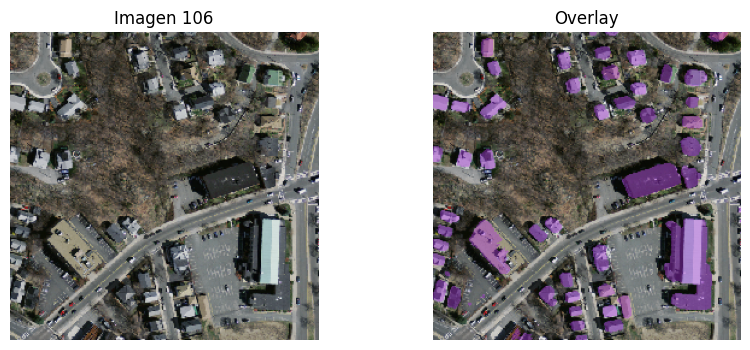

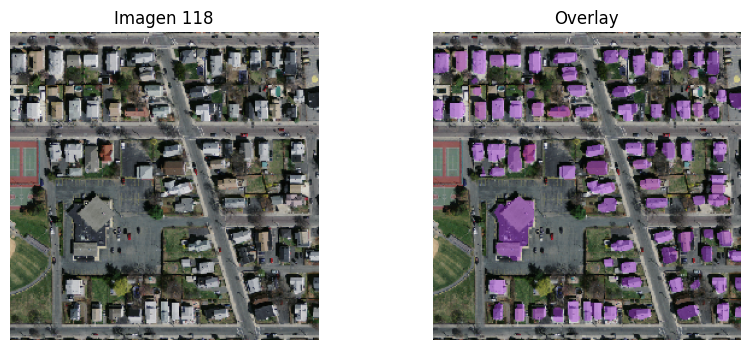

In [31]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch

for _ in range(2):
    idx = random.randint(0, len(test_dataset) - 1)

    image, mask = test_dataset[idx]
    image_input = image.unsqueeze(0)

    model.eval()
    with torch.no_grad():
        output = model(image_input)
        pred = torch.sigmoid(output)
        pred = (pred > 0.6).float()

    img_np = image.permute(1, 2, 0).numpy()
    mask_pred_np = pred.squeeze().numpy()

    overlay = img_np.copy()
    alpha = 0.4
    overlay[mask_pred_np == 1] = (
        alpha * np.array([0.7, 0.2, 0.9]) +
        (1 - alpha) * overlay[mask_pred_np == 1]
    )

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(img_np)
    plt.title(f"Imagen {idx}")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

    plt.show()

# FUNCIONES DE METRICAS

In [33]:
# Esta función calcula la IoU (Intersection over Union)
# Sirve para medir cuánto se solapan la máscara predicha y la máscara real
def iou_score(pred, target):
    # Calculamos los píxeles que coinciden como positivos en ambas máscaras
    intersection = (pred * target).sum().item()
    
    # Calculamos la unión:
    # todos los píxeles positivos en predicción y en máscara real,
    # sin contar dos veces la intersección
    union = pred.sum().item() + target.sum().item() - intersection
    
    # Devolvemos la IoU
    # Sumamos 1e-8 para evitar división entre 0
    return intersection / (union + 1e-8)


# Esta función calcula el Dice Score
# Es otra métrica de solapamiento, muy usada en segmentación
def dice_score(pred, target):
    # Calculamos los píxeles positivos que coinciden en ambas máscaras
    intersection = (pred * target).sum().item()
    
    # Aplicamos la fórmula del Dice:
    # 2 * intersección / (positivos predichos + positivos reales)
    return (2 * intersection) / (pred.sum().item() + target.sum().item() + 1e-8)


# Esta función calcula la accuracy
# Mide el porcentaje total de píxeles clasificados correctamente
def accuracy_score(pred, target):
    # Comparamos píxel a píxel si la predicción y la máscara real son iguales
    correct = (pred == target).sum().item()
    
    # Calculamos el número total de píxeles
    total = target.numel()
    
    # Devolvemos la accuracy
    return correct / total


# Esta función calcula la precision
# Mide, de todos los píxeles que el modelo ha marcado como tejado,
# cuántos eran realmente tejado
def precision_score(pred, target):
    # Verdaderos positivos:
    # píxeles que el modelo predijo como 1 y en la realidad también son 1
    tp = ((pred == 1) & (target == 1)).sum().item()
    
    # Falsos positivos:
    # píxeles que el modelo predijo como 1 pero en realidad son 0
    fp = ((pred == 1) & (target == 0)).sum().item()
    
    # Devolvemos la precision
    return tp / (tp + fp + 1e-8)


# Esta función calcula el recall
# Mide, de todos los tejados reales,
# cuántos ha sido capaz de detectar el modelo
def recall_score(pred, target):
    # Verdaderos positivos:
    # píxeles correctamente detectados como tejado
    tp = ((pred == 1) & (target == 1)).sum().item()
    
    # Falsos negativos:
    # píxeles que eran tejado pero el modelo no detectó
    fn = ((pred == 0) & (target == 1)).sum().item()
    
    # Devolvemos el recall
    return tp / (tp + fn + 1e-8)

# EVALUACION EN TEST

# NO CORRER OTRA VEZ

In [37]:
# Ponemos el modelo en modo evaluación
# Esto es importante para que capas como BatchNorm o Dropout
# funcionen en modo inferencia y no en modo entrenamiento
model.eval()

# Creamos listas vacías para ir guardando el valor de cada métrica
# en cada batch del conjunto de test
iou_list = []
dice_list = []
accuracy_list = []
precision_list = []
recall_list = []

# Desactivamos el cálculo de gradientes
# Esto hace que la evaluación sea más rápida y consuma menos memoria
with torch.no_grad():
    
    # Recorremos todos los batches del test_loader
    for images, masks in test_loader:
        
        # Pasamos las imágenes por el modelo para obtener la salida
        outputs = model(images)
        
        # Aplicamos sigmoide para convertir la salida en probabilidades
        preds = torch.sigmoid(outputs)
        
        # Convertimos las probabilidades en 0 y 1 usando un threshold
        # Usamos 0.85 porque visualmente te había funcionado mejor
        preds = (preds > 0.6).float()
        
        # Calculamos cada métrica para este batch
        iou = iou_score(preds, masks)
        dice = dice_score(preds, masks)
        acc = accuracy_score(preds, masks)
        prec = precision_score(preds, masks)
        rec = recall_score(preds, masks)
        
        # Guardamos cada resultado en su lista correspondiente
        iou_list.append(iou)
        dice_list.append(dice)
        accuracy_list.append(acc)
        precision_list.append(prec)
        recall_list.append(rec)

# MEDIA FINAL DE LAS METRICAS

In [ ]:
# Calculamos la media de cada lista de métricas
# np.mean sirve para sacar el promedio de todos los valores guardados
mean_iou = np.mean(iou_list)
mean_dice = np.mean(dice_list)
mean_accuracy = np.mean(accuracy_list)
mean_precision = np.mean(precision_list)
mean_recall = np.mean(recall_list)

# Mostramos los resultados finales en pantalla
# Usamos :.4f para que salgan con 4 decimales y quede más limpio
print(f"IoU media: {mean_iou:.4f}")
print(f"Dice media: {mean_dice:.4f}")
print(f"Accuracy media: {mean_accuracy:.4f}")
print(f"Precision media: {mean_precision:.4f}")
print(f"Recall media: {mean_recall:.4f}")

# ANÁLISIS DE THRESHOLD

In [ ]:
thresholds = [0.5, 0.6, 0.7, 0.8, 0.9]

for th in thresholds:
    iou_list = []
    dice_list = []

    model.eval()
    with torch.no_grad():
        for images, masks in test_loader:
            outputs = model(images)
            preds = torch.sigmoid(outputs)
            preds = (preds > th).float()

            iou = iou_score(preds, masks)
            dice = dice_score(preds, masks)

            iou_list.append(iou)
            dice_list.append(dice)

    print(f"Threshold {th}")
    print(f"IoU: {np.mean(iou_list):.4f}")
    print(f"Dice: {np.mean(dice_list):.4f}")
    print("------")

# PRUEBA CON IMAGENES DE SOLARMAP

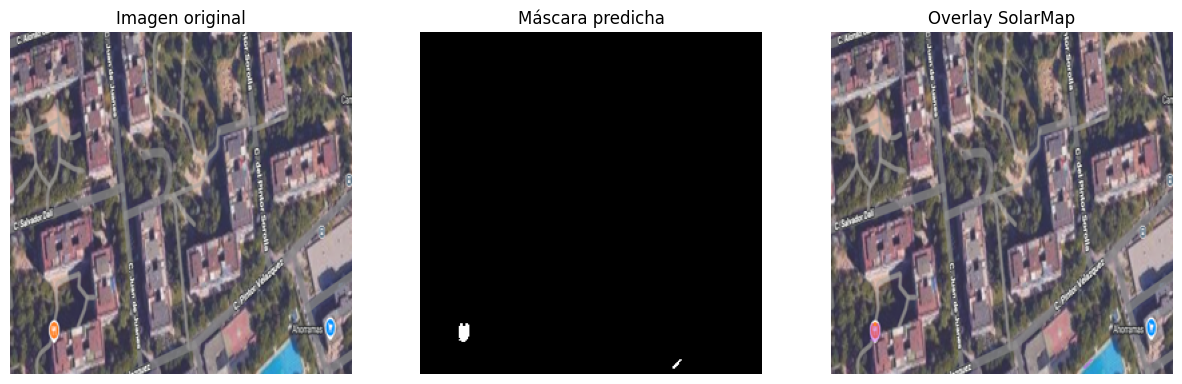

In [28]:
from PIL import Image
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------
# 1. RUTA DE LA IMAGEN
# ------------------------------

# ⚠️ CAMBIA SOLO EL NOMBRE DEL ARCHIVO
# deja la ruta igual si usas la carpeta FotosSolarMap
image_path = Path("ModeloDeteccionTejados/FotosSolarMap/mapa1.png")

# ------------------------------
# 2. CARGAR IMAGEN
# ------------------------------

# Abrimos la imagen y la convertimos a RGB
image = Image.open(image_path).convert("RGB")

# Redimensionamos a 256x256 (MUY IMPORTANTE)
image = image.resize((256, 256))

# ------------------------------
# 3. PREPROCESADO
# ------------------------------

# Convertimos a array y normalizamos (0-1)
img_np = np.array(image) / 255.0

# Convertimos a tensor y cambiamos formato (H,W,C → C,H,W)
image_tensor = torch.tensor(img_np, dtype=torch.float32).permute(2, 0, 1)

# Añadimos dimensión batch (1,C,H,W)
image_input = image_tensor.unsqueeze(0)

# ------------------------------
# 4. PREDICCION
# ------------------------------

model.eval()

with torch.no_grad():
    output = model(image_input)
    pred = torch.sigmoid(output)

    # ⚠️ USAMOS EL THRESHOLD OPTIMO
    pred = (pred > 0.6).float()

# Convertimos predicción a numpy
mask_pred = pred.squeeze().numpy()

# ------------------------------
# 5. OVERLAY MORADO TRANSPARENTE
# ------------------------------

overlay = img_np.copy()

alpha = 0.4

overlay[mask_pred == 1] = (
    alpha * np.array([0.7, 0.2, 0.9]) +
    (1 - alpha) * overlay[mask_pred == 1]
)

# ------------------------------
# 6. VISUALIZACION
# ------------------------------

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_np)
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask_pred, cmap="gray")
plt.title("Máscara predicha")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title("Overlay SolarMap")
plt.axis("off")

plt.show()

ModuleNotFoundError: No module named 'cv2'

In [46]:
import sys
!{sys.executable} -m pip install opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   -- ------------------------------------- 2.4/40.2 MB 12.2 MB/s eta 0:00:04
   ---- ----------------------------------- 5.0/40.2 MB 12.6 MB/s eta 0:00:03
   ------- -------------------------------- 7.9/40.2 MB 12.8 MB/s eta 0:00:03
   ---------- ----------------------------- 10.5/40.2 MB 12.6 MB/s eta 0:00:03
   ------------- -------------------------- 13.4/40.2 MB 12.7 MB/s eta 0:00:03
   ---------------- ----------------------- 16.3/40.2 MB 12.6 MB/s eta 0:00:02
   ------------------ --------------------- 18.9/40.2 MB 12.7 MB/s eta 0:00:02
   --------------------- ------------------ 21.8/40.2 MB 12.7 MB/s eta 0:00:02
   ----------------------- ---------------- 24.1/40.2 MB 12.7 MB/s eta 0:00:02
   -------------------------- ------------- 27.0/40.2 MB 12.7 MB/s eta 0:00:02
   ----------------------------- ---------- 29.9/40.2 MB 12.7 MB/s eta 0:00:01
   -------------------------------- ------- 32.8/40.2 MB 12.7 MB

In [73]:
import numpy as np
import cv2
import json
import math

# ---------------------------------------------------
# CONFIGURACIÓN
# ---------------------------------------------------

metadata_path = "mapa_limpio_metadata.json"
output_geojson_path = "tejados.geojson"

# Si salen demasiadas manchas pequeñas, sube este valor
# Para zoom 18 recomiendo 80-150
# Para zoom 19 recomiendo 150-300
area_minima_px = 100

# ---------------------------------------------------
# 1. PREPARAR MÁSCARA
# ---------------------------------------------------

if hasattr(mask, "detach"):
    mask_np = mask.squeeze().detach().cpu().numpy()
else:
    mask_np = np.squeeze(mask)

mask_np = (mask_np > 0.5).astype(np.uint8)

print("Shape máscara:", mask_np.shape)
print("Valores únicos:", np.unique(mask_np))

# ---------------------------------------------------
# 2. CARGAR METADATA
# ---------------------------------------------------

with open(metadata_path, "r", encoding="utf-8") as f:
    metadata = json.load(f)

top_left = metadata["bbox"]["top_left"]
top_right = metadata["bbox"]["top_right"]
bottom_left = metadata["bbox"]["bottom_left"]

lat_max = top_left["lat"]
lat_min = bottom_left["lat"]

lon_min = top_left.get("lon", top_left.get("lng"))
lon_max = top_right.get("lon", top_right.get("lng"))

area_m2_per_pixel = metadata["meters_per_pixel"]["area_m2_per_pixel"]

H, W = mask_np.shape

# ---------------------------------------------------
# 3. FUNCIONES AUXILIARES
# ---------------------------------------------------

def pixel_to_geo(x, y):
    lon = lon_min + (x / W) * (lon_max - lon_min)
    lat = lat_max - (y / H) * (lat_max - lat_min)
    return [float(lon), float(lat)]


def calcular_orientacion(cnt):
    puntos = cnt.reshape(-1, 2).astype(np.float32)

    if len(puntos) < 2:
        return None, "No calculable"

    mean, eigenvectors = cv2.PCACompute(puntos, mean=None)
    vx, vy = eigenvectors[0]

    angulo = math.degrees(math.atan2(vy, vx))

    # Normalizar entre 0 y 180 porque una dirección y su opuesta representan el mismo eje
    if angulo < 0:
        angulo += 180

    if angulo >= 180:
        angulo -= 180

    # Clasificación aproximada
    if 0 <= angulo < 22.5 or 157.5 <= angulo <= 180:
        orientacion = "Este-Oeste"
    elif 22.5 <= angulo < 67.5:
        orientacion = "Noroeste-Sureste"
    elif 67.5 <= angulo < 112.5:
        orientacion = "Norte-Sur"
    else:
        orientacion = "Noreste-Suroeste"

    return float(round(angulo, 2)), orientacion

# ---------------------------------------------------
# 4. COMPONENTES CONECTADAS
# ---------------------------------------------------

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    mask_np,
    connectivity=8
)

features = []

for label in range(1, num_labels):

    area_px_componente = stats[label, cv2.CC_STAT_AREA]

    if area_px_componente < area_minima_px:
        continue

    component = (labels == label).astype(np.uint8) * 255

    contours, _ = cv2.findContours(
        component,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    for cnt in contours:

        area_px = cv2.contourArea(cnt)

        if area_px < area_minima_px:
            continue

        epsilon = 0.01 * cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, epsilon, True)

        coords = []

        for point in approx:
            x, y = point[0]
            coords.append(pixel_to_geo(x, y))

        if len(coords) < 3:
            continue

        if coords[0] != coords[-1]:
            coords.append(coords[0])

        area_m2 = area_px * area_m2_per_pixel

        angulo, orientacion = calcular_orientacion(cnt)

        feature = {
            "type": "Feature",
            "geometry": {
                "type": "Polygon",
                "coordinates": [coords]
            },
            "properties": {
                "id": len(features) + 1,
                "zoom": metadata.get("zoom"),
                "area_px": float(round(area_px, 2)),
                "area_m2": float(round(area_m2, 2)),
                "orientation_angle_degrees": angulo,
                "orientation_label": orientacion
            }
        }

        features.append(feature)

# ---------------------------------------------------
# 5. EXPORTAR GEOJSON
# ---------------------------------------------------

geojson = {
    "type": "FeatureCollection",
    "features": features
}

with open(output_geojson_path, "w", encoding="utf-8") as f:
    json.dump(geojson, f, indent=4, ensure_ascii=False)

print("GeoJSON generado correctamente")
print("Número de tejados detectados:", len(features))
print("Archivo creado:", output_geojson_path)

for feature in features:
    props = feature["properties"]
    print(
        f"Tejado {props['id']} | "
        f"Área: {props['area_m2']} m² | "
        f"Orientación: {props['orientation_label']} | "
        f"Ángulo: {props['orientation_angle_degrees']}º"
    )

Shape máscara: (256, 256)
Valores únicos: [0 1]
GeoJSON generado correctamente
Número de tejados detectados: 19
Archivo creado: tejados.geojson
Tejado 1 | Área: 148.87 m² | Orientación: Norte-Sur | Ángulo: 90.0º
Tejado 2 | Área: 114.23 m² | Orientación: Norte-Sur | Ángulo: 90.19º
Tejado 3 | Área: 123.02 m² | Orientación: Norte-Sur | Ángulo: 90.0º
Tejado 4 | Área: 129.74 m² | Orientación: Norte-Sur | Ángulo: 87.52º
Tejado 5 | Área: 110.62 m² | Orientación: Este-Oeste | Ángulo: 178.05º
Tejado 6 | Área: 108.55 m² | Orientación: Norte-Sur | Ángulo: 90.0º
Tejado 7 | Área: 108.03 m² | Orientación: Norte-Sur | Ángulo: 91.68º
Tejado 8 | Área: 108.03 m² | Orientación: Este-Oeste | Ángulo: 169.62º
Tejado 9 | Área: 148.87 m² | Orientación: Norte-Sur | Ángulo: 90.0º
Tejado 10 | Área: 127.67 m² | Orientación: Norte-Sur | Ángulo: 104.13º
Tejado 11 | Área: 133.88 m² | Orientación: Norte-Sur | Ángulo: 91.08º
Tejado 12 | Área: 151.97 m² | Orientación: Este-Oeste | Ángulo: 174.65º
Tejado 13 | Área: 110.

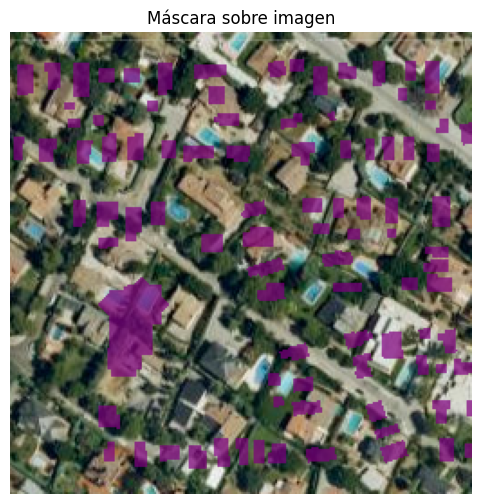

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# -------------------------------
# 1. CARGAR IMAGEN ORIGINAL
# -------------------------------

img = Image.open("mapa_limpio.png")
img_np = np.array(img)

# -------------------------------
# 2. PREPARAR MÁSCARA
# -------------------------------

if hasattr(mask, "detach"):
    mask_np = mask.squeeze().detach().cpu().numpy()
else:
    mask_np = np.squeeze(mask)

mask_np = (mask_np > 0.5).astype(np.uint8)

# -------------------------------
# 3. CREAR OVERLAY MORADO
# -------------------------------

overlay = np.zeros((256, 256, 4), dtype=np.uint8)

# Morado (R,G,B,A)
overlay[..., 0] = 128   # rojo
overlay[..., 1] = 0     # verde
overlay[..., 2] = 128   # azul

# Transparencia solo donde hay tejado
overlay[..., 3] = mask_np * 180  # alpha (0 transparente, 180 visible)

# -------------------------------
# 4. MOSTRAR
# -------------------------------

plt.figure(figsize=(6,6))

# Imagen base
plt.imshow(img_np)

# Overlay
plt.imshow(overlay)

plt.title("Máscara sobre imagen")
plt.axis("off")

plt.show()

Shape máscara predicha: (256, 256)
Valores únicos: [0 1]


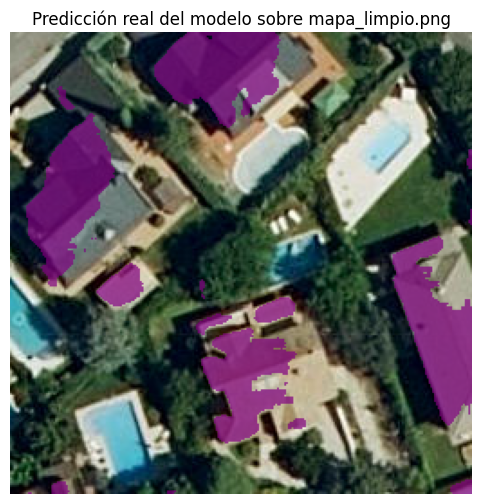

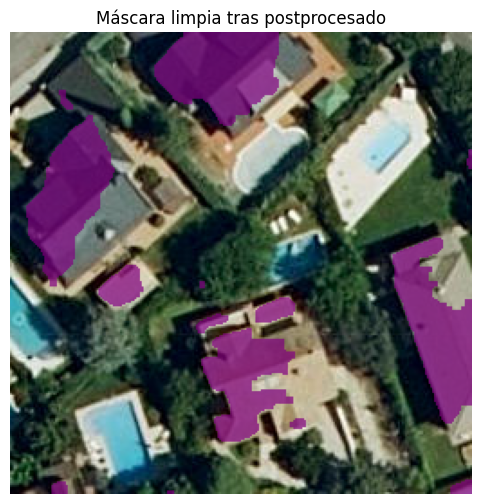

GeoJSON generado correctamente
Número de tejados detectados: 6
Archivo creado: tejados.geojson
Tejado 1 | Área: 204.39 m² | Orientación: Este-Oeste | Ángulo: 1.68º
Tejado 2 | Área: 189.45 m² | Orientación: Norte-Sur | Ángulo: 105.28º
Tejado 3 | Área: 186.47 m² | Orientación: Norte-Sur | Ángulo: 81.32º
Tejado 4 | Área: 28.76 m² | Orientación: Noreste-Suroeste | Ángulo: 147.79º
Tejado 5 | Área: 15.85 m² | Orientación: Este-Oeste | Ángulo: 179.64º
Tejado 6 | Área: 144.59 m² | Orientación: Norte-Sur | Ángulo: 86.02º


In [84]:
import torch
import numpy as np
import cv2
import json
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
import math

# ---------------------------------------------------
# CONFIGURACIÓN
# ---------------------------------------------------

image_path = "mapa_limpio.png"
metadata_path = "mapa_limpio_metadata.json"
output_geojson_path = "tejados.geojson"

threshold = 0.70
area_minima_px = 150

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------------------------------
# 1. CARGAR IMAGEN REAL
# ---------------------------------------------------

img = Image.open(image_path).convert("RGB")

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

input_tensor = transform(img).unsqueeze(0).to(device)

# ---------------------------------------------------
# 2. PREDICCIÓN REAL DEL MODELO
# ---------------------------------------------------

model = model.to(device)
model.eval()

with torch.no_grad():
    output = model(input_tensor)
    pred = torch.sigmoid(output)
    pred_mask = (pred > threshold).float()

mask_np = pred_mask.squeeze().cpu().numpy().astype(np.uint8)

print("Shape máscara predicha:", mask_np.shape)
print("Valores únicos:", np.unique(mask_np))

# ---------------------------------------------------
# 3. MOSTRAR MÁSCARA SOBRE IMAGEN REAL
# ---------------------------------------------------

img_np = np.array(img)

overlay = np.zeros((256, 256, 4), dtype=np.uint8)
overlay[..., 0] = 128
overlay[..., 1] = 0
overlay[..., 2] = 128
overlay[..., 3] = mask_np * 180

plt.figure(figsize=(6, 6))
plt.imshow(img_np)
plt.imshow(overlay)
plt.title("Predicción real del modelo sobre mapa_limpio.png")
plt.axis("off")
plt.show()

# ---------------------------------------------------
# 4. CARGAR METADATA
# ---------------------------------------------------

with open(metadata_path, "r", encoding="utf-8") as f:
    metadata = json.load(f)

top_left = metadata["bbox"]["top_left"]
top_right = metadata["bbox"]["top_right"]
bottom_left = metadata["bbox"]["bottom_left"]

lat_max = top_left["lat"]
lat_min = bottom_left["lat"]

lon_min = top_left.get("lon", top_left.get("lng"))
lon_max = top_right.get("lon", top_right.get("lng"))

area_m2_per_pixel = metadata["meters_per_pixel"]["area_m2_per_pixel"]

H, W = mask_np.shape

def pixel_to_geo(x, y):
    lon = lon_min + (x / W) * (lon_max - lon_min)
    lat = lat_max - (y / H) * (lat_max - lat_min)
    return [float(lon), float(lat)]

def calcular_orientacion(cnt):
    puntos = cnt.reshape(-1, 2).astype(np.float32)

    if len(puntos) < 2:
        return None, "No calculable"

    mean, eigenvectors = cv2.PCACompute(puntos, mean=None)
    vx, vy = eigenvectors[0]

    angulo = math.degrees(math.atan2(vy, vx))

    if angulo < 0:
        angulo += 180

    if angulo >= 180:
        angulo -= 180

    if 0 <= angulo < 22.5 or 157.5 <= angulo <= 180:
        orientacion = "Este-Oeste"
    elif 22.5 <= angulo < 67.5:
        orientacion = "Noroeste-Sureste"
    elif 67.5 <= angulo < 112.5:
        orientacion = "Norte-Sur"
    else:
        orientacion = "Noreste-Suroeste"

    return float(round(angulo, 2)), orientacion

# ---------------------------------------------------
# 5. POSTPROCESADO
# ---------------------------------------------------

kernel_open = np.ones((3, 3), np.uint8)
kernel_close = np.ones((5, 5), np.uint8)

mask_clean = cv2.morphologyEx(mask_np, cv2.MORPH_OPEN, kernel_open)
mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_CLOSE, kernel_close)

# ---------------------------------------------------
# 6. MOSTRAR MÁSCARA LIMPIA
# ---------------------------------------------------

overlay_clean = np.zeros((256, 256, 4), dtype=np.uint8)
overlay_clean[..., 0] = 128
overlay_clean[..., 1] = 0
overlay_clean[..., 2] = 128
overlay_clean[..., 3] = mask_clean * 180

plt.figure(figsize=(6, 6))
plt.imshow(img_np)
plt.imshow(overlay_clean)
plt.title("Máscara limpia tras postprocesado")
plt.axis("off")
plt.show()

# ---------------------------------------------------
# 7. CONTORNOS Y GEOJSON
# ---------------------------------------------------

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    mask_clean,
    connectivity=8
)

features = []

for label in range(1, num_labels):

    area_px_componente = stats[label, cv2.CC_STAT_AREA]

    if area_px_componente < area_minima_px:
        continue

    component = (labels == label).astype(np.uint8) * 255

    contours, _ = cv2.findContours(
        component,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    for cnt in contours:

        area_px = cv2.contourArea(cnt)

        if area_px < area_minima_px:
            continue

        epsilon = 0.01 * cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, epsilon, True)

        coords = []

        for point in approx:
            x, y = point[0]
            coords.append(pixel_to_geo(x, y))

        if len(coords) < 3:
            continue

        if coords[0] != coords[-1]:
            coords.append(coords[0])

        area_m2 = area_px * area_m2_per_pixel
        angulo, orientacion = calcular_orientacion(cnt)

        feature = {
            "type": "Feature",
            "geometry": {
                "type": "Polygon",
                "coordinates": [coords]
            },
            "properties": {
                "id": len(features) + 1,
                "zoom": metadata.get("zoom"),
                "threshold": threshold,
                "area_px": float(round(area_px, 2)),
                "area_m2": float(round(area_m2, 2)),
                "orientation_angle_degrees": angulo,
                "orientation_label": orientacion
            }
        }

        features.append(feature)

geojson = {
    "type": "FeatureCollection",
    "features": features
}

with open(output_geojson_path, "w", encoding="utf-8") as f:
    json.dump(geojson, f, indent=4, ensure_ascii=False)

print("GeoJSON generado correctamente")
print("Número de tejados detectados:", len(features))
print("Archivo creado:", output_geojson_path)

for feature in features:
    props = feature["properties"]
    print(
        f"Tejado {props['id']} | "
        f"Área: {props['area_m2']} m² | "
        f"Orientación: {props['orientation_label']} | "
        f"Ángulo: {props['orientation_angle_degrees']}º"
    )